In [1]:
!pip install requests beautifulsoup4 pandas

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import random

urls = [
    "https://en.wikipedia.org/wiki/List_of_restaurant_chains",
    "https://en.wikipedia.org/wiki/List_of_fast_food_restaurant_chains",
    "https://en.wikipedia.org/wiki/List_of_coffeehouse_chains",
    "https://en.wikipedia.org/wiki/List_of_pizza_chains",
    "https://en.wikipedia.org/wiki/List_of_bakery_cafes",
    "https://en.wikipedia.org/wiki/List_of_chicken_restaurants",
    "https://en.wikipedia.org/wiki/List_of_ice_cream_parlor_chains",
    "https://en.wikipedia.org/wiki/List_of_hamburger_restaurants",
    "https://en.wikipedia.org/wiki/List_of_doughnut_shops",
    "https://en.wikipedia.org/wiki/List_of_sandwich_shops",
    "https://en.wikipedia.org/wiki/List_of_fried_chicken_restaurants",
    "https://en.wikipedia.org/wiki/List_of_food_companies",
    "https://en.wikipedia.org/wiki/List_of_restaurant_chains_in_the_United_States",
    "https://en.wikipedia.org/wiki/List_of_casual_dining_restaurant_chains",
    #"https://en.wikipedia.org/wiki/List_of_Asian_restaurant_chains",
    #"https://en.wikipedia.org/wiki/List_of_Italian_restaurants",
    #"https://en.wikipedia.org/wiki/List_of_Indian_restaurant_chains",
    #"https://en.wikipedia.org/wiki/List_of_Chinese_restaurants",
    #"https://en.wikipedia.org/wiki/List_of_Japanese_restaurants",
    #"https://en.wikipedia.org/wiki/List_of_seafood_restaurants",
    #"https://en.wikipedia.org/wiki/List_of_steakhouses",
    #"https://en.wikipedia.org/wiki/List_of_buffet_restaurants",
    #"https://en.wikipedia.org/wiki/List_of_pancake_houses",
    #"https://en.wikipedia.org/wiki/List_of_barbecue_restaurants"
]

headers = {
    "User-Agent": "Mozilla/5.0"
}

city_area_map = {
    "Bangalore": ["Indiranagar", "Whitefield", "Banashankari"],
    "Mumbai": ["Andheri", "Navi Mumbai", "Colaba"],
    "Delhi": ["Connaught Place", "Saket", "Rohini"],
    "Kochi": ["Kakkanad", "Fort Kochi", "palarivattom"]
}

data = []
restaurant_location_map = {}
# cities for location

for url in urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    tables = soup.find_all("table", class_="wikitable")

    for table in tables:
        rows = table.find_all("tr")

        for row in rows[1:]:
            cols = row.find_all("td")

            if len(cols) > 0:
                name = cols[0].text.strip()

                # 🔹 Cuisine based on name
                name_lower = name.lower()
                if "cafe" in name_lower or "coffee" in name_lower:
                   cuisine = "Cafe"
                elif "pizza" in name_lower:
                   cuisine = "Italian"
                elif "burger" in name_lower:
                   cuisine = "Fast Food"
                elif "chicken" in name_lower:
                   cuisine = "Fast Food"
                elif "kfc" in name_lower:
                   cuisine = "Fast Food"
                elif "subway" in name_lower:
                   cuisine = "Fast Food"
                elif "ice cream" in name_lower:
                   cuisine = "Dessert"
                elif "donut" in name_lower:
                   cuisine = "Dessert"
                else:
                   cuisine = "Restaurant"

                # 🔹 Price and avg_cost_for_two
                choice = random.choice(["Low", "Medium", "High"])
                price = choice

                if choice == "Low":
                   avg_cost_for_two = random.randint(100, 400)

                elif choice == "Medium":
                   avg_cost_for_two = random.randint(400, 1200)
                else:
                   avg_cost_for_two = random.randint(1200, 2500)


                #Restaurant Type
                if "cafe" in cuisine.lower():
                   restaurant_type = "Cafe"
                elif "dessert" in cuisine.lower():
                   restaurant_type = "Dessert"
                elif avg_cost_for_two > 1200:
                   restaurant_type = "Fine Dining"
                elif avg_cost_for_two < 400:
                    restaurant_type = "Fast Food"
                else:
                   restaurant_type = "Casual Dining"


                #reviews
                reviews = random.randint(10, 5000)

                #Number of Ratings
                num_ratings = int(random.triangular(10, 5000, 500))

                #online delivery
                if avg_cost_for_two > 1500 and restaurant_type == "Fine Dining" :
                  online_delivery= 'No'  # fine dining usually no delivery

                else:
                   online_delivery = random.choices(["Yes", "No"],
                   weights = [0.7, 0.3])[0]


                # 🔹  rating (random, as no 'card' object for wikitable)
                rating = round(random.uniform(2.5, 5.0), 1)


                #table booking
                if restaurant_type == "Fine Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[0.8, 0.2])[0]

                elif restaurant_type == "Casual Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[0.5, 0.5])[0]

                else:  # Fast Food / Cafe
                    table_booking = random.choices(["Yes", "No"], weights=[0.2, 0.8])[0]


                # 🔹 Random location
                if name in restaurant_location_map:
                   location = restaurant_location_map[name]
                else:
                     city = random.choice(list(city_area_map.keys()))
                     area = random.choice(city_area_map[city])
                     location = f"{area}, {city}"
                     restaurant_location_map[name] = location


                # switch_to_order_menu
                if online_delivery == "Yes":
                    switch_to_order_menu = "Yes"
                else:
                    switch_to_order_menu = "No"

                # is_delivering_now
                if online_delivery == "No":
                    is_delivering_now = "No"
                else:
                    is_delivering_now = random.choices(["Yes", "No"], weights=[0.7, 0.3])[0]

                data.append({
                   "name": name,
                    "url": url,
                   "rating": rating,
                  "location": location,
                   "city":city,
                   "area":area,
                  "cuisine": cuisine,
                  "price": price,
                  "reviews": reviews,
                 "restaurant_type": restaurant_type,
                 "num_ratings": num_ratings,
                "online_delivery": online_delivery,
                "table_booking": table_booking,
                "avg_cost_for_two": avg_cost_for_two,
                "is_delivering_now": is_delivering_now,
                 "switch_to_order_menu": switch_to_order_menu
})

df1 = pd.DataFrame(data)

print("Rows collected:", len(df1))
df1.head()

Rows collected: 1505


,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,85°C Bakery Cafe,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Cafe,Low,1609,Cafe,1992,Yes,No,349,No,Yes
1,Applebee's,https://en.wikipedia.org/wiki/List_of_restaura...,4.7,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,1424,Casual Dining,2702,No,No,566,No,No
2,Arby's,https://en.wikipedia.org/wiki/List_of_restaura...,4.2,"Kakkanad, Kochi",Kochi,Kakkanad,Restaurant,High,3384,Fine Dining,3690,No,No,1352,No,No
3,Auntie Anne's,https://en.wikipedia.org/wiki/List_of_restaura...,3.0,"Navi Mumbai, Mumbai",Mumbai,Navi Mumbai,Restaurant,Medium,1731,Casual Dining,3521,Yes,Yes,1106,No,Yes
4,Barista,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,3900,Casual Dining,4612,Yes,No,947,Yes,Yes


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import random

urls = [

    "https://en.wikipedia.org/wiki/List_of_buffet_restaurants",
"https://en.wikipedia.org/wiki/List_of_steakhouses",
"https://en.wikipedia.org/wiki/List_of_seafood_restaurants",
"https://en.wikipedia.org/wiki/List_of_vegetarian_restaurants",
"https://en.wikipedia.org/wiki/List_of_brewery_restaurants",
"https://en.wikipedia.org/wiki/List_of_food_trucks",
"https://en.wikipedia.org/wiki/List_of_juice_bars",
"https://en.wikipedia.org/wiki/List_of_supermarket_chains",
"https://en.wikipedia.org/wiki/List_of_convenience_stores",
"https://en.wikipedia.org/wiki/List_of_cafeterias",
"https://en.wikipedia.org/wiki/List_of_hotel_chains",
"https://en.wikipedia.org/wiki/List_of_catering_companies",
"https://en.wikipedia.org/wiki/List_of_pub_chains",
"https://en.wikipedia.org/wiki/List_of_family_restaurants",
"https://en.wikipedia.org/wiki/List_of_international_restaurant_chains",
'https://en.wikipedia.org/wiki/List_of_diner_chains',
'https://en.wikipedia.org/wiki/List_of_sushi_restaurants',
'https://en.wikipedia.org/wiki/List_of_taco_restaurants',
'https://en.wikipedia.org/wiki/List_of_buffalo_wing_restaurants',
    'https://en.wikipedia.org/wiki/List_of_pancake_houses'

]

headers = {
    "User-Agent": "Mozilla/5.0"
}
city_area_map = {
    "Bangalore": ["Indiranagar", "Whitefield", "MG Road"],
    "Mumbai": ["Andheri", "Bandra", "Colaba"],
    "Delhi": ["Connaught Place", "Saket", "Karol Bagh"],
    "Kochi": ["Kakkanad", "Fort Kochi", "Edappally"]
}

data = []
restaurant_location_map = {}
# cities for location

for url in urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    tables = soup.find_all("table", class_="wikitable")

    for table in tables:
        rows = table.find_all("tr")

        for row in rows[1:]:
            cols = row.find_all("td")

            if len(cols) > 0:
                name = cols[0].text.strip()

                #reviews
                import random
                reviews = random.randint(10, 5000)

                #Restaurant Type
                if "cafe" in cuisine.lower():
                   restaurant_type = "Cafe"
                elif "dessert" in cuisine.lower():
                   restaurant_type = "Dessert"
                elif avg_cost_for_two > 1200:
                   restaurant_type = "Fine Dining"
                elif avg_cost_for_two < 400:
                    restaurant_type = "Fast Food"
                else:
                   restaurant_type = "Casual Dining"

                #Number of Ratings
                num_ratings = int(random.triangular(10, 5000, 500))

                #online delivery
                if avg_cost_for_two > 1500 and restaurant_type == "Fine Dining" :
                  online_delivery= 'No'  # fine dining usually no delivery

                else:
                   online_delivery = random.choices(["Yes", "No"],
                   weights = [0.7, 0.3])[0]


                # 🔹  rating
            try:
                rating_tag = card.select_one('.rating-class')  # change to real class
                if rating_tag:
                    rating_text = rating_tag.text.strip()
                    rating = float(rating_text.split()[0])
                else:
                    raise Exception("No rating found")
            except:
                import random
                rating = round(random.uniform(2.5, 5.0), 1)


                #table booking


                if restaurant_type == "Fine Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[80, 20])[0]

                elif restaurant_type == "Casual Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[50, 50])[0]

                else:  # Fast Food / Cafe
                    table_booking = random.choices(["Yes", "No"], weights=[20, 80])[0]


                #average cost (for 2 ppls)
                if restaurant_type == "Fast Food":
                   avg_cost_for_two = random.randint(150, 399)

                elif restaurant_type == "Cafe":
                   avg_cost_for_two = random.randint(400, 799)

                elif restaurant_type == "Casual Dining":
                    avg_cost_for_two = random.randint(800, 1199)

                elif restaurant_type == "Fine Dining":
                    avg_cost_for_two = random.randint(1200, 3000)

                else:
                   avg_cost_for_two = random.randint(400, 999)

                # 🔹 Random location

                if name in restaurant_location_map:
                   location = restaurant_location_map[name]
                else:
                     city = random.choice(list(city_area_map.keys()))
                     area = random.choice(city_area_map[city])
                     location = f"{area}, {city}"
                     restaurant_location_map[name] = location



                # 🔹 Cuisine based on name
                name_lower = name.lower()

                if "cafe" in name_lower or "coffee" in name_lower:
                   cuisine = "Cafe"
                elif "pizza" in name_lower:
                   cuisine = "Italian"
                elif "burger" in name_lower:
                   cuisine = "Fast Food"
                elif "chicken" in name_lower:
                   cuisine = "Fast Food"
                elif "kfc" in name_lower:
                   cuisine = "Fast Food"
                elif "subway" in name_lower:
                   cuisine = "Fast Food"
                elif "ice cream" in name_lower:
                   cuisine = "Dessert"
                elif "donut" in name_lower:
                   cuisine = "Dessert"
                else:
                   cuisine = "Restaurant"


                # switch_to_order_menu
                if online_delivery == "Yes":
                    switch_to_order_menu = "Yes"
                else:
                    switch_to_order_menu = "No"

                # is_delivering_now
                if online_delivery == "No":
                    is_delivering_now = "No"
                else:
                    is_delivering_now = random.choices(["Yes", "No"], weights=[70, 30])[0]

                # 🔹 Price
                import random

                choice = random.choice(["Low", "Medium", "High"])

                if choice == "Low":
                   avg_cost_for_two = random.randint(100, 400)

                elif choice == "Medium":
                   avg_cost_for_two = random.randint(400, 1200)
                else:
                   avg_cost_for_two = random.randint(1200, 2500)
                   restaurant_type = "Fine Dining"
                price = choice

                data.append({
                   "name": name,
                    "url": url,
                   "rating": rating,#target
                  "location": location,
                   "city":city,
                   "area":area,
                  "cuisine": cuisine,
                  "price": price,
                  "reviews": reviews,
                 "restaurant_type": restaurant_type,
                 "num_ratings": num_ratings,
                "online_delivery": online_delivery,
                "table_booking": table_booking,
                "avg_cost_for_two": avg_cost_for_two,
                "is_delivering_now": is_delivering_now,
                 "switch_to_order_menu": switch_to_order_menu
})

df2 = pd.DataFrame(data)

print("Rows collected:", len(df2))
df2.head()

Rows collected: 423


,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,7-Eleven,https://en.wikipedia.org/wiki/List_of_supermar...,2.8,"Indiranagar, Bangalore",Bangalore,Indiranagar,Restaurant,High,2934,Fine Dining,822,Yes,No,2284,Yes,Yes
1,Aeon,https://en.wikipedia.org/wiki/List_of_supermar...,4.2,"Edappally, Kochi",Kochi,Edappally,Restaurant,Low,3261,Fine Dining,433,No,Yes,366,No,No
2,Ahold Delhaize,https://en.wikipedia.org/wiki/List_of_supermar...,3.4,"Connaught Place, Delhi",Delhi,Connaught Place,Restaurant,Low,3780,Fast Food,3529,Yes,Yes,178,Yes,Yes
3,Aldi,https://en.wikipedia.org/wiki/List_of_supermar...,4.7,"Whitefield, Bangalore",Bangalore,Whitefield,Restaurant,High,4180,Fine Dining,1202,No,No,2018,No,No
4,Edeka,https://en.wikipedia.org/wiki/List_of_supermar...,4.0,"Whitefield, Bangalore",Bangalore,Whitefield,Restaurant,Low,3757,Fine Dining,2320,No,Yes,362,No,No


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import random

urls = [
    "https://en.wikipedia.org/wiki/List_of_pancake_houses",
    "https://en.wikipedia.org/wiki/List_of_hamburger_restaurants",
    "https://en.wikipedia.org/wiki/List_of_doughnut_shops",
    "https://en.wikipedia.org/wiki/List_of_sandwich_shops",
    "https://en.wikipedia.org/wiki/List_of_fried_chicken_restaurants",
    "https://en.wikipedia.org/wiki/List_of_ice_cream_parlor_chains",
    "https://en.wikipedia.org/wiki/List_of_coffeehouse_chains",
    "https://en.wikipedia.org/wiki/List_of_fast_food_restaurant_chains",
    "https://en.wikipedia.org/wiki/List_of_restaurant_chains",
    "https://en.wikipedia.org/wiki/List_of_pizza_chains"
]


headers = {
    "User-Agent": "Mozilla/5.0"
}
city_area_map = {
    "Bangalore": ["Indiranagar", "Whitefield", "MG Road"],
    "Mumbai": ["Andheri", "Bandra", "Colaba"],
    "Delhi": ["Connaught Place", "Saket", "Karol Bagh"],
    "Kochi": ["Kakkanad", "Fort Kochi", "Edappally"]
}

data = []
restaurant_location_map = {}
# cities for location

for url in urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    tables = soup.find_all("table", class_="wikitable")

    for table in tables:
        rows = table.find_all("tr")

        for row in rows[1:]:
            cols = row.find_all("td")

            if len(cols) > 0:
                name = cols[0].text.strip()

                #reviews
                import random
                reviews = random.randint(10, 5000)

                #Restaurant Type
                if "cafe" in cuisine.lower():
                   restaurant_type = "Cafe"
                elif "dessert" in cuisine.lower():
                   restaurant_type = "Dessert"
                elif avg_cost_for_two > 1200:
                   restaurant_type = "Fine Dining"
                elif avg_cost_for_two < 400:
                    restaurant_type = "Fast Food"
                else:
                   restaurant_type = "Casual Dining"

                #Number of Ratings
                num_ratings = int(random.triangular(10, 5000, 500))

                #online delivery
                if avg_cost_for_two > 1500 and restaurant_type == "Fine Dining" :
                  online_delivery= 'No'  # fine dining usually no delivery

                else:
                   online_delivery = random.choices(["Yes", "No"],
                   weights = [0.7, 0.3])[0]


                # 🔹  rating
            try:
                rating_tag = card.select_one('.rating-class')  # change to real class
                if rating_tag:
                    rating_text = rating_tag.text.strip()
                    rating = float(rating_text.split()[0])
                else:
                    raise Exception("No rating found")
            except:
                import random
                rating = round(random.uniform(2.5, 5.0), 1)


                #table booking


                if restaurant_type == "Fine Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[80, 20])[0]

                elif restaurant_type == "Casual Dining":
                    table_booking = random.choices(["Yes", "No"], weights=[50, 50])[0]

                else:  # Fast Food / Cafe
                    table_booking = random.choices(["Yes", "No"], weights=[20, 80])[0]


                #average cost (for 2 ppls)
                if restaurant_type == "Fast Food":
                   avg_cost_for_two = random.randint(150, 399)

                elif restaurant_type == "Cafe":
                   avg_cost_for_two = random.randint(400, 799)

                elif restaurant_type == "Casual Dining":
                    avg_cost_for_two = random.randint(800, 1199)

                elif restaurant_type == "Fine Dining":
                    avg_cost_for_two = random.randint(1200, 3000)

                else:
                   avg_cost_for_two = random.randint(400, 999)

                # 🔹 Random location

                if name in restaurant_location_map:
                   location = restaurant_location_map[name]
                else:
                     city = random.choice(list(city_area_map.keys()))
                     area = random.choice(city_area_map[city])
                     location = f"{area}, {city}"
                     restaurant_location_map[name] = location



                # 🔹 Cuisine based on name
                name_lower = name.lower()

                if "cafe" in name_lower or "coffee" in name_lower:
                   cuisine = "Cafe"
                elif "pizza" in name_lower:
                   cuisine = "Italian"
                elif "burger" in name_lower:
                   cuisine = "Fast Food"
                elif "chicken" in name_lower:
                   cuisine = "Fast Food"
                elif "kfc" in name_lower:
                   cuisine = "Fast Food"
                elif "subway" in name_lower:
                   cuisine = "Fast Food"
                elif "ice cream" in name_lower:
                   cuisine = "Dessert"
                elif "donut" in name_lower:
                   cuisine = "Dessert"
                else:
                   cuisine = "Restaurant"


                # switch_to_order_menu
                if online_delivery == "Yes":
                    switch_to_order_menu = "Yes"
                else:
                    switch_to_order_menu = "No"

                # is_delivering_now
                if online_delivery == "No":
                    is_delivering_now = "No"
                else:
                    is_delivering_now = random.choices(["Yes", "No"], weights=[70, 30])[0]

                # 🔹 Price
                import random

                choice = random.choice(["Low", "Medium", "High"])

                if choice == "Low":
                   avg_cost_for_two = random.randint(100, 400)

                elif choice == "Medium":
                   avg_cost_for_two = random.randint(400, 1200)
                else:
                   avg_cost_for_two = random.randint(1200, 2500)
                   restaurant_type = "Fine Dining"
                price = choice

                data.append({
                   "name": name,
                    "url": url,
                   "rating": rating,#target
                  "location": location,
                   "city":city,
                   "area":area,
                  "cuisine": cuisine,
                  "price": price,
                  "reviews": reviews,
                 "restaurant_type": restaurant_type,
                 "num_ratings": num_ratings,
                "online_delivery": online_delivery,
                "table_booking": table_booking,
                "avg_cost_for_two": avg_cost_for_two,
                "is_delivering_now": is_delivering_now,
                 "switch_to_order_menu": switch_to_order_menu
})

df3 = pd.DataFrame(data)

print("Rows collected:", len(df3))
df3.head()

Rows collected: 394


,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,Allie's Donuts,https://en.wikipedia.org/wiki/List_of_doughnut...,4.4,"Andheri, Mumbai",Mumbai,Andheri,Dessert,High,498,Fine Dining,1677,Yes,No,1321,Yes,Yes
1,BeaverTails,https://en.wikipedia.org/wiki/List_of_doughnut...,4.4,"Indiranagar, Bangalore",Bangalore,Indiranagar,Restaurant,Low,1999,Dessert,1055,Yes,No,133,Yes,Yes
2,Bess Eaton,https://en.wikipedia.org/wiki/List_of_doughnut...,4.3,"Connaught Place, Delhi",Delhi,Connaught Place,Restaurant,Low,3908,Fast Food,967,Yes,No,102,Yes,Yes
3,Big Apple Donuts and Coffee,https://en.wikipedia.org/wiki/List_of_doughnut...,3.7,"Andheri, Mumbai",Mumbai,Andheri,Cafe,High,4751,Fine Dining,640,Yes,No,2239,No,Yes
4,Café du Monde,https://en.wikipedia.org/wiki/List_of_doughnut...,3.8,"Connaught Place, Delhi",Delhi,Connaught Place,Restaurant,High,1032,Fine Dining,1940,No,No,1592,No,No


In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re

headers = {
    "User-Agent": "Mozilla/5.0"
}

# 🔥 Cities list (areas will be auto-collected)
cities = [
    "bangalore","Firozabad", "chennai", "hyderabad", "mumbai", "delhi",'Karnataka',"Tamil Nadu",
    "pune", "kolkata", "ahmedabad", "jaipur", "lucknow","Maharashtra",
    "chandigarh", "kochi", "coimbatore", "indore", "bhopal","Baraut","Uttar Pradesh","Madhya Pradesh","Rajasthan",
    "surat", "nagpur", "trivandrum", "madurai", "vizag","Khambhalia","Hazaribagh","Gurugram","New Delhi"
]

data = []

# 🔥 Get areas dynamically
def get_areas(city):
    url = f"https://www.zomato.com/{city}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")

    areas = []
    links = soup.find_all("a", href=True)

    for link in links:
        href = link["href"]
        if f"/{city}/" in href and "-restaurants" in href:
            area = href.split(f"/{city}/")[-1].replace("-restaurants", "")
            areas.append(area)

    return list(set(areas))


# 🔥 MAIN SCRAPER
for city in cities:
    print(f"\n🔍 Collecting areas for {city}...")
    areas = get_areas(city)

    print(f"➡ Found {len(areas)} areas")

    for area in areas:
        for page in range(1, 3):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print("Scraping:", city, area, "Page:", page)

            try:
                response = requests.get(url, headers=headers)
                soup = BeautifulSoup(response.text, "lxml")

                cards = soup.find_all("div", class_="jumbo-tracker")

                if len(cards) == 0:
                    continue

                for card in cards:
                    try:
                        # Name
                        name_tag = card.find("h4")
                        name = name_tag.text.strip() if name_tag else None

                        # Cuisine
                        cuisine_tag = card.find("p")
                        cuisine = cuisine_tag.get_text().strip() if cuisine_tag else None

                        # ❌ Remove offers
                        if cuisine and re.search(r'\d+%|off|₹', cuisine.lower()):
                            cuisine = None

                        # Price
                        price_tag = card.find(string=lambda text: text and "₹" in text)
                        price_text = price_tag.strip() if price_tag else None

                        if price_text:
                            numbers = re.findall(r'\d+', price_text.replace(",", ""))
                            avg_cost_for_two = int(numbers[0]) if numbers else None
                        else:
                            avg_cost_for_two = None

                        # Price category
                        if avg_cost_for_two:
                            if avg_cost_for_two < 400:
                                price = "Low"
                            elif avg_cost_for_two < 1200:
                                price = "Medium"
                            else:
                                price = "High"
                        else:
                            price = None

                        # Rating
                        rating_tag = card.find(string=lambda x: x and "." in x and len(x) < 5)
                        rating = float(rating_tag.strip()) if rating_tag else None

                        # Location
                        location = f"{area.replace('-', ' ').title()}, {city.title()}"

                        # =========================
                        # 🔥 REALISTIC LOGIC START
                        # =========================

                        # Restaurant Type
                        if cuisine:
                            if "cafe" in cuisine.lower():
                                restaurant_type = "Cafe"
                            elif "dessert" in cuisine.lower():
                                restaurant_type = "Dessert"
                            elif avg_cost_for_two and avg_cost_for_two > 1200:
                                restaurant_type = "Fine Dining"
                            elif avg_cost_for_two and avg_cost_for_two < 400:
                                restaurant_type = "Fast Food"
                            else:
                                restaurant_type = "Casual Dining"
                        else:
                            restaurant_type = "Casual Dining"

                        # Number of ratings (realistic distribution)
                        num_ratings = int(random.triangular(10, 5000, 500))

                        # Reviews (slightly less than ratings)
                        reviews = int(num_ratings * random.uniform(0.3, 0.9))

                        # Online delivery
                        if avg_cost_for_two and avg_cost_for_two > 1500 and restaurant_type == "Fine Dining":
                            online_delivery = 'No'
                        else:
                            online_delivery = random.choices(
                                ["Yes", "No"],
                                weights=[0.7, 0.3]
                            )[0]

                        # Table booking
                        if restaurant_type == "Fine Dining":
                            table_booking = random.choices(["Yes", "No"], weights=[80, 20])[0]
                        elif restaurant_type == "Casual Dining":
                            table_booking = random.choices(["Yes", "No"], weights=[50, 50])[0]
                        else:
                            table_booking = random.choices(["Yes", "No"], weights=[20, 80])[0]

                        # Switch to order menu
                        if online_delivery == "Yes":
                            switch_to_order_menu = "Yes"
                        else:
                            switch_to_order_menu = "No"

                        # Is delivering now
                        if online_delivery == "No":
                            is_delivering_now = "No"
                        else:
                            is_delivering_now = random.choices(
                                ["Yes", "No"],
                                weights=[70, 30]
                            )[0]

                        # =========================
                        # 🔥 FINAL DATA APPEND
                        # =========================

                        if name:
                            data.append({
                                "name": name,
                                "url": url,
                                "location": location,
                                "city": city.title(),
                                "area": area.replace('-', ' ').title(),
                                "cuisine": cuisine,
                                "price": price,
                                "avg_cost_for_two": avg_cost_for_two,
                                "rating": rating,
                                "restaurant_type": restaurant_type,
                                "reviews": reviews,
                                "num_ratings": num_ratings,
                                "online_delivery": online_delivery,
                                "table_booking": table_booking,
                                "is_delivering_now": is_delivering_now,
                                "switch_to_order_menu": switch_to_order_menu
                            })

                    except Exception as e:
                        print("Card error:", e)

                time.sleep(2)

            except Exception as e:
                print("Page error:", e)


# ✅ Create DataFrame
df4 = pd.DataFrame(data)

print("\n✅ Total Rows Collected:", len(df4))

# ❌ RAW DATA (no duplicate removal)
# df4.drop_duplicates(inplace=True)

# Save
df4.to_csv("zomato_raw_dataset.csv", index=False)

print("✅ Raw dataset saved successfully!")
df4.head()


🔍 Collecting areas for bangalore...
➡ Found 3 areas
Scraping: bangalore romantic Page: 1
Scraping: bangalore romantic Page: 2
Scraping: bangalore fine-dining Page: 1
Scraping: bangalore fine-dining Page: 2
Scraping: bangalore iconic Page: 1
Scraping: bangalore iconic Page: 2

🔍 Collecting areas for Firozabad...
➡ Found 0 areas

🔍 Collecting areas for chennai...
➡ Found 8 areas
Scraping: chennai thuraipakkam Page: 1
Scraping: chennai thuraipakkam Page: 2
Scraping: chennai t-nagar Page: 1
Scraping: chennai t-nagar Page: 2
Scraping: chennai adyar Page: 1
Scraping: chennai adyar Page: 2
Scraping: chennai velachery Page: 1
Scraping: chennai velachery Page: 2
Scraping: chennai anna-nagar-east Page: 1
Scraping: chennai anna-nagar-east Page: 2
Scraping: chennai alwarpet Page: 1
Scraping: chennai alwarpet Page: 2
Scraping: chennai mylapore Page: 1
Scraping: chennai mylapore Page: 2
Scraping: chennai nungambakkam Page: 1
Scraping: chennai nungambakkam Page: 2

🔍 Collecting areas for hyderabad..

,name,url,location,city,area,cuisine,price,avg_cost_for_two,rating,restaurant_type,reviews,num_ratings,online_delivery,table_booking,is_delivering_now,switch_to_order_menu
0,Zhouyu ECR - A Chinese | Asian Kitchen,https://www.zomato.com/chennai/thuraipakkam-re...,"Thuraipakkam, Chennai",Chennai,Thuraipakkam,"Chinese, Asian, Seafood",Medium,1000,4.6,Casual Dining,166,316,No,No,No,No
1,Crazy Ivan Resto Lounge,https://www.zomato.com/chennai/thuraipakkam-re...,"Thuraipakkam, Chennai",Chennai,Thuraipakkam,"North Indian, Chinese, Continental, Biryani, P...",High,2200,4.4,Fine Dining,1320,1589,No,No,No,No
2,Bayroot,https://www.zomato.com/chennai/thuraipakkam-re...,"Thuraipakkam, Chennai",Chennai,Thuraipakkam,"North Indian, Chinese, Oriental, Arabian, Sush...",High,2000,4.6,Dessert,355,812,No,No,No,No
3,VGP Annachi's Kitchen - Since 1974,https://www.zomato.com/chennai/thuraipakkam-re...,"Thuraipakkam, Chennai",Chennai,Thuraipakkam,"South Indian, Andhra, Desserts, Shake, Beverages",Medium,800,3.8,Dessert,2200,4380,Yes,No,Yes,Yes
4,Booze Republic,https://www.zomato.com/chennai/thuraipakkam-re...,"Thuraipakkam, Chennai",Chennai,Thuraipakkam,North Indian,High,1500,3.9,Fine Dining,149,191,No,Yes,No,No


In [6]:
df4['switch_to_order_menu'].value_counts()

,count
switch_to_order_menu,
Yes,968
No,796


In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re

headers = {
    "User-Agent": "Mozilla/5.0"
}

# 🔥 Cities list (areas will be auto-collected)
cities = [
    "durgapur","rourkela","agra","dhanbad","visakhapatnam","salem","","haldia",
    "ahmedabad", "ajmer", "alappuzha", "allahabad", "amravati",
    "amritsar", "aurangabad", "bhubaneswar", "chandigarh", "chennai",
    "coimbatore", "cuttack", "dehradun","goa"
]

data = []

# 🔥 Get areas dynamically
def get_areas(city):
    url = f"https://www.zomato.com/{city}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")

    areas = []
    links = soup.find_all("a", href=True)

    for link in links:
        href = link["href"]
        if f"/{city}/" in href and "-restaurants" in href:
            area = href.split(f"/{city}/")[-1].replace("-restaurants", "")
            areas.append(area)

    return list(set(areas))


# 🔥 MAIN SCRAPER
for city in cities:
    print(f"\n🔍 Collecting areas for {city}...")
    areas = get_areas(city)

    print(f"➡ Found {len(areas)} areas")

    for area in areas:
        for page in range(1, 3):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print("Scraping:", city, area, "Page:", page)

            try:
                response = requests.get(url, headers=headers)
                soup = BeautifulSoup(response.text, "lxml")

                cards = soup.find_all("div", class_="jumbo-tracker")

                if len(cards) == 0:
                    continue

                for card in cards:
                    try:
                        # Name
                        name_tag = card.find("h4")
                        name = name_tag.text.strip() if name_tag else None

                        # Cuisine
                        cuisine_tag = card.find("p")
                        cuisine = cuisine_tag.get_text().strip() if cuisine_tag else None

                        # ❌ Remove offers
                        if cuisine and re.search(r'\d+%|off|₹', cuisine.lower()):
                            cuisine = None

                        # Price
                        price_tag = card.find(string=lambda text: text and "₹" in text)
                        price_text = price_tag.strip() if price_tag else None

                        if price_text:
                            numbers = re.findall(r'\d+', price_text.replace(",", ""))
                            avg_cost_for_two = int(numbers[0]) if numbers else None
                        else:
                            avg_cost_for_two = None

                        # Price category
                        if avg_cost_for_two:
                            if avg_cost_for_two < 400:
                                price = "Low"
                            elif avg_cost_for_two < 1200:
                                price = "Medium"
                            else:
                                price = "High"
                        else:
                            price = None

                        # Rating
                        rating_tag = card.find(string=lambda x: x and "." in x and len(x) < 5)
                        rating = float(rating_tag.strip()) if rating_tag else None

                        # Location
                        location = f"{area.replace('-', ' ').title()}, {city.title()}"

                        # =========================
                        # 🔥 REALISTIC LOGIC START
                        # =========================

                        # Restaurant Type
                        if cuisine:
                            if "cafe" in cuisine.lower():
                                restaurant_type = "Cafe"
                            elif "dessert" in cuisine.lower():
                                restaurant_type = "Dessert"
                            elif avg_cost_for_two and avg_cost_for_two > 1200:
                                restaurant_type = "Fine Dining"
                            elif avg_cost_for_two and avg_cost_for_two < 400:
                                restaurant_type = "Fast Food"
                            else:
                                restaurant_type = "Casual Dining"
                        else:
                            restaurant_type = "Casual Dining"

                        # Number of ratings (realistic distribution)
                        num_ratings = int(random.triangular(10, 5000, 500))

                        # Reviews (slightly less than ratings)
                        reviews = int(num_ratings * random.uniform(0.3, 0.9))

                        # Online delivery
                        if avg_cost_for_two and avg_cost_for_two > 1500 and restaurant_type == "Fine Dining":
                            online_delivery = 'No'
                        else:
                            online_delivery = random.choices(
                                ["Yes", "No"],
                                weights=[0.7, 0.3]
                            )[0]

                        # Table booking
                        if restaurant_type == "Fine Dining":
                            table_booking = random.choices(["Yes", "No"], weights=[80, 20])[0]
                        elif restaurant_type == "Casual Dining":
                            table_booking = random.choices(["Yes", "No"], weights=[50, 50])[0]
                        else:
                            table_booking = random.choices(["Yes", "No"], weights=[20, 80])[0]

                        # Switch to order menu
                        if online_delivery == "Yes":
                            switch_to_order_menu = "Yes"
                        else:
                            switch_to_order_menu = "No"

                        # Is delivering now
                        if online_delivery == "No":
                            is_delivering_now = "No"
                        else:
                            is_delivering_now = random.choices(
                                ["Yes", "No"],
                                weights=[70, 30]
                            )[0]

                        # =========================
                        # 🔥 FINAL DATA APPEND
                        # =========================

                        if name:
                            data.append({
                                "name": name,
                                "url": url,
                                "location": location,
                                "city": city.title(),
                                "area": area.replace('-', ' ').title(),
                                "cuisine": cuisine,
                                "price": price,
                                "avg_cost_for_two": avg_cost_for_two,
                                "rating": rating,
                                "restaurant_type": restaurant_type,
                                "reviews": reviews,
                                "num_ratings": num_ratings,
                                "online_delivery": online_delivery,
                                "table_booking": table_booking,
                                "is_delivering_now": is_delivering_now,
                                "switch_to_order_menu": switch_to_order_menu
                            })

                    except Exception as e:
                        print("Card error:", e)

                time.sleep(2)

            except Exception as e:
                print("Page error:", e)


# ✅ Create DataFrame
df5 = pd.DataFrame(data)

print("\n✅ Total Rows Collected:", len(df5))

# ❌ RAW DATA (no duplicate removal)
# df4.drop_duplicates(inplace=True)

# Save
df5.to_csv("zomato_raw_dataset.csv", index=False)

print("✅ Raw dataset saved successfully!")
df5.head()


🔍 Collecting areas for durgapur...
➡ Found 1 areas
Scraping: durgapur durgapur-locality Page: 1
Scraping: durgapur durgapur-locality Page: 2

🔍 Collecting areas for rourkela...
➡ Found 8 areas
Scraping: rourkela chhend-colony Page: 1
Scraping: rourkela chhend-colony Page: 2
Scraping: rourkela udit-nagar Page: 1
Scraping: rourkela udit-nagar Page: 2
Scraping: rourkela sector-6 Page: 1
Scraping: rourkela sector-6 Page: 2
Scraping: rourkela koel-nagar Page: 1
Scraping: rourkela koel-nagar Page: 2
Scraping: rourkela raghunathpali Page: 1
Scraping: rourkela raghunathpali Page: 2
Scraping: rourkela raurkela-industrialship Page: 1
Scraping: rourkela raurkela-industrialship Page: 2
Scraping: rourkela railway-colony Page: 1
Scraping: rourkela railway-colony Page: 2
Scraping: rourkela basanti-nagar Page: 1
Scraping: rourkela basanti-nagar Page: 2

🔍 Collecting areas for agra...
➡ Found 10 areas
Scraping: agra 6-taj-view Page: 1
Scraping: agra 6-taj-view Page: 2
Scraping: agra kamla-nagar Page: 

,name,url,location,city,area,cuisine,price,avg_cost_for_two,rating,restaurant_type,reviews,num_ratings,online_delivery,table_booking,is_delivering_now,switch_to_order_menu
0,Epar Bangla Opar Bangla,https://www.zomato.com/durgapur/durgapur-local...,"Durgapur Locality, Durgapur",Durgapur,Durgapur Locality,None,Low,200.0,4.2,Casual Dining,1535,1706,No,No,No,No
1,Monginis Cake Shop,https://www.zomato.com/durgapur/durgapur-local...,"Durgapur Locality, Durgapur",Durgapur,Durgapur Locality,None,Low,200.0,4.3,Casual Dining,1475,2114,Yes,No,Yes,Yes
2,Hestia Bakehouse,https://www.zomato.com/durgapur/durgapur-local...,"Durgapur Locality, Durgapur",Durgapur,Durgapur Locality,None,Low,150.0,4.4,Casual Dining,2951,3390,Yes,Yes,Yes,Yes
3,WOW! Chicken By WOW! Momo,https://www.zomato.com/durgapur/durgapur-local...,"Durgapur Locality, Durgapur",Durgapur,Durgapur Locality,None,Low,150.0,3.9,Casual Dining,681,775,Yes,No,Yes,Yes
4,Domino's Pizza,https://www.zomato.com/durgapur/durgapur-local...,"Durgapur Locality, Durgapur",Durgapur,Durgapur Locality,None,Low,100.0,4.3,Casual Dining,1704,1916,Yes,Yes,Yes,Yes


In [8]:
df5['cuisine'].value_counts()

,count
cuisine,
"North Indian, BBQ, Kebab, Biryani",48
"Pizza, Fast Food, Desserts, Beverages",16
"North Indian, Chinese, Pizza, Fast Food, Street Food, Beverages",16
"North Indian, South Indian, Fast Food, Sandwich, Beverages, Desserts",16
"Pizza, Fast Food, Pasta, Burger, Wraps, Beverages",16
...,...
"North Indian, Continental, Chinese, Fast Food, Desserts, Beverages",1
"North Indian, Biryani, Mughlai, Roast Chicken, Seafood",1
"North Indian, Chinese, Momos, Fast Food, Pizza, Burger, Beverages",1


In [9]:
df5.isnull().sum()

,0
name,0
url,0
location,0
city,0
area,0
cuisine,706
price,2
avg_cost_for_two,2
rating,78
restaurant_type,0


In [10]:
raw_df = pd.concat([df1, df2, df3,df4,df5])

name
location (city + area combine)
cuisine
price_range
num_ratings
online_delivery
table_booking
avg_cost_for_two
rating  (TARGET)

In [11]:
raw_df.head()

,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,85°C Bakery Cafe,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Cafe,Low,1609,Cafe,1992,Yes,No,349.0,No,Yes
1,Applebee's,https://en.wikipedia.org/wiki/List_of_restaura...,4.7,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,1424,Casual Dining,2702,No,No,566.0,No,No
2,Arby's,https://en.wikipedia.org/wiki/List_of_restaura...,4.2,"Kakkanad, Kochi",Kochi,Kakkanad,Restaurant,High,3384,Fine Dining,3690,No,No,1352.0,No,No
3,Auntie Anne's,https://en.wikipedia.org/wiki/List_of_restaura...,3.0,"Navi Mumbai, Mumbai",Mumbai,Navi Mumbai,Restaurant,Medium,1731,Casual Dining,3521,Yes,Yes,1106.0,No,Yes
4,Barista,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,3900,Casual Dining,4612,Yes,No,947.0,Yes,Yes


In [12]:
raw_df.to_csv("zomato_raw_dataset.csv", index=False)

###EDA

In [13]:
raw_df.shape

(6608, 16)

In [14]:
raw_df.isnull().sum()

,0
name,0
url,0
rating,150
location,0
city,0
area,0
cuisine,866
price,2
reviews,0
restaurant_type,0


In [15]:
df =raw_df.drop_duplicates(subset=['name', 'location'], keep='first')


In [16]:
df.shape

(3809, 16)

In [17]:
df.isnull().sum()

,0
name,0
url,0
rating,74
location,0
city,0
area,0
cuisine,410
price,1
reviews,0
restaurant_type,0


In [18]:
df.shape

(3809, 16)

In [19]:
#visulisation

In [20]:
df.groupby(['rating','restaurant_type']).size().reset_index(name = 'count')

,rating,restaurant_type,count
0,2.5,Cafe,4
1,2.5,Casual Dining,11
2,2.5,Dessert,2
3,2.5,Fast Food,10
4,2.5,Fine Dining,19
...,...,...,...
124,5.0,Cafe,3
125,5.0,Casual Dining,9
126,5.0,Dessert,1
127,5.0,Fast Food,7


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

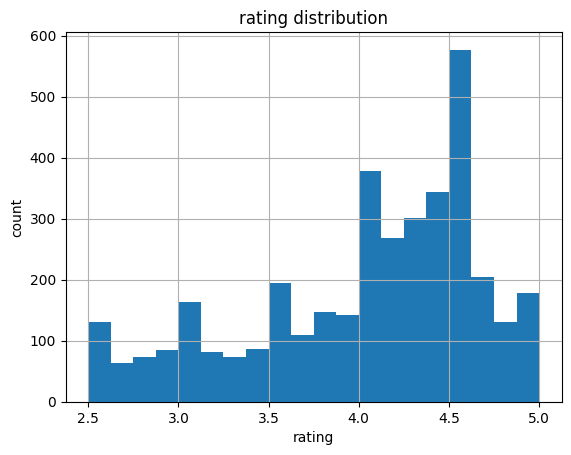

In [22]:
df['rating'].hist(bins=20)   # how rating are spread
plt.title("rating distribution")
plt.xlabel("rating")
plt.ylabel("count")
plt.show()

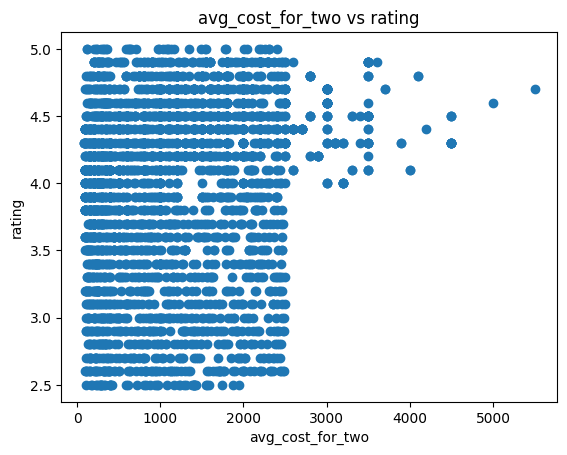

In [23]:
plt.scatter(df['avg_cost_for_two'], df['rating'])
plt.title("avg_cost_for_two vs rating")    #relationship
plt.xlabel("avg_cost_for_two")
plt.ylabel("rating")
plt.show()

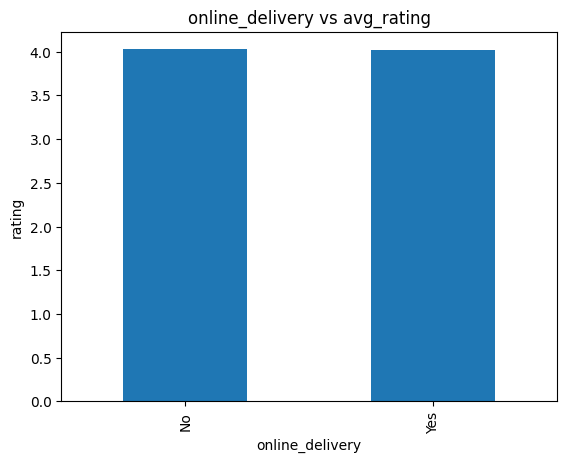

In [24]:
df.groupby('online_delivery')['rating'].mean().plot(kind='bar')   #online delivery Vs rating
plt.title("online_delivery vs avg_rating")
plt.xlabel("online_delivery")
plt.ylabel("rating")
plt.show()

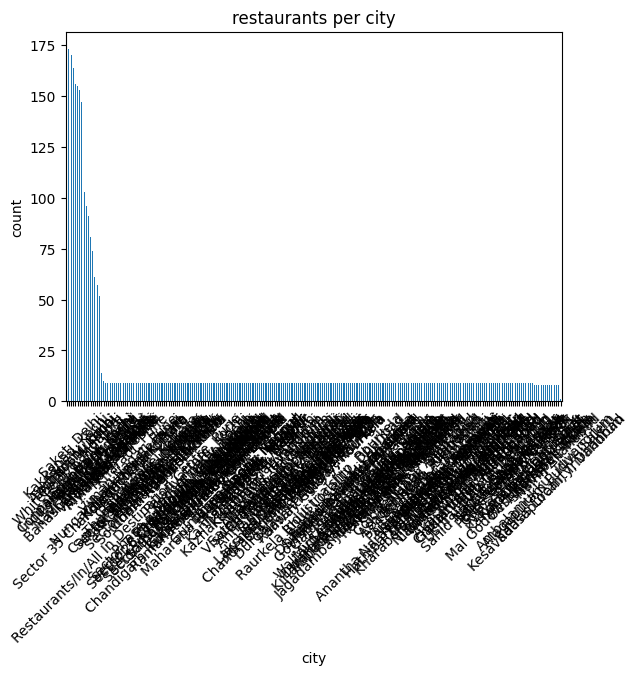

In [25]:
df['location'].value_counts().plot(kind='bar')    #city distribution
plt.title("restaurants per city")
plt.xlabel("city")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

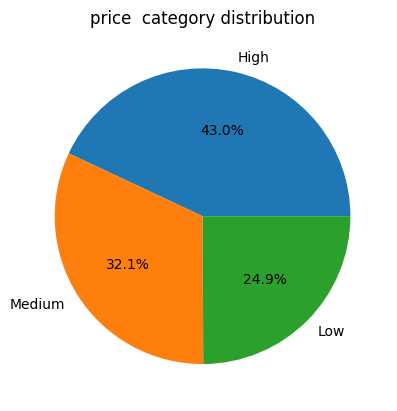

In [26]:
df['price'].value_counts().plot(kind='pie',autopct = "%1.1f%%" )   #price distribution
plt.title("price  category distribution")
plt.ylabel("")
plt.show()

In [27]:
# univarient analysis

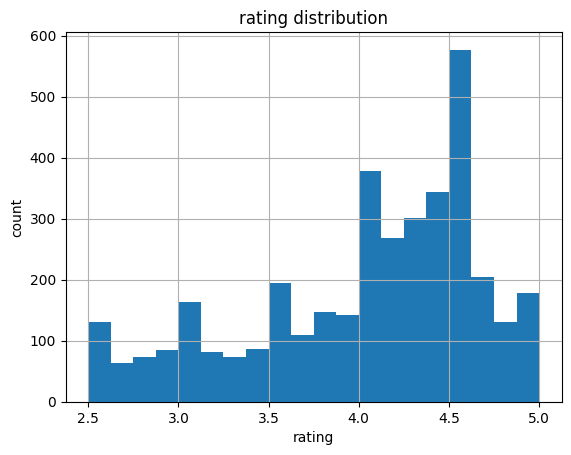

In [28]:
df['rating'].hist(bins=20)   # how rating are spread
plt.title("rating distribution")
plt.xlabel("rating")
plt.ylabel("count")
plt.show()
#

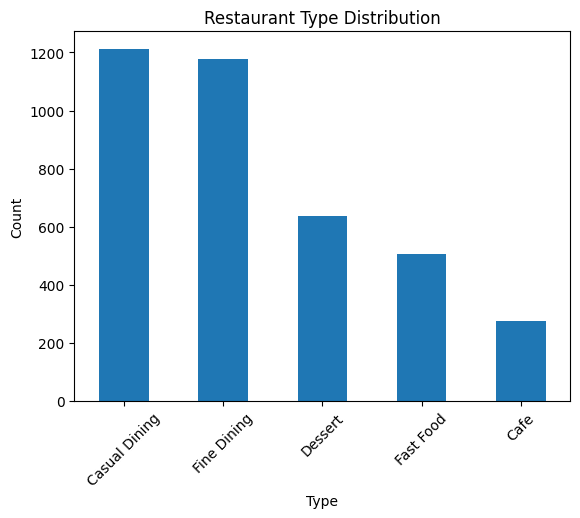

In [29]:
df['restaurant_type'].value_counts().plot(kind='bar')
plt.title("Restaurant Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

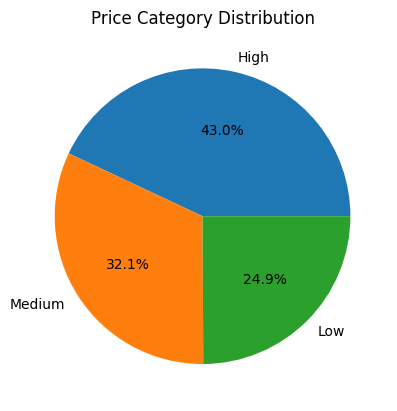

In [30]:
df['price'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Price Category Distribution")
plt.ylabel("")
plt.show()

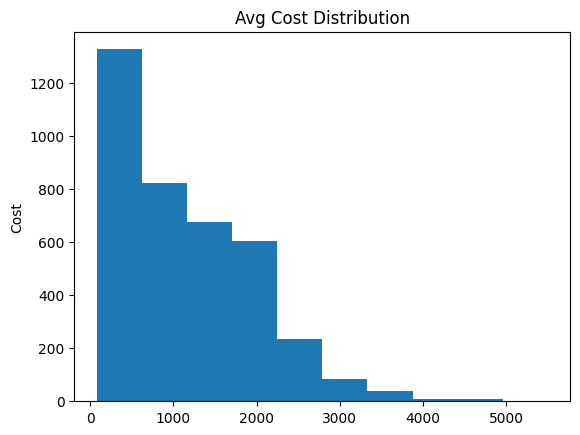

In [31]:
plt.hist(df['avg_cost_for_two'])
plt.title("Avg Cost Distribution")
plt.ylabel("Cost")
plt.show()

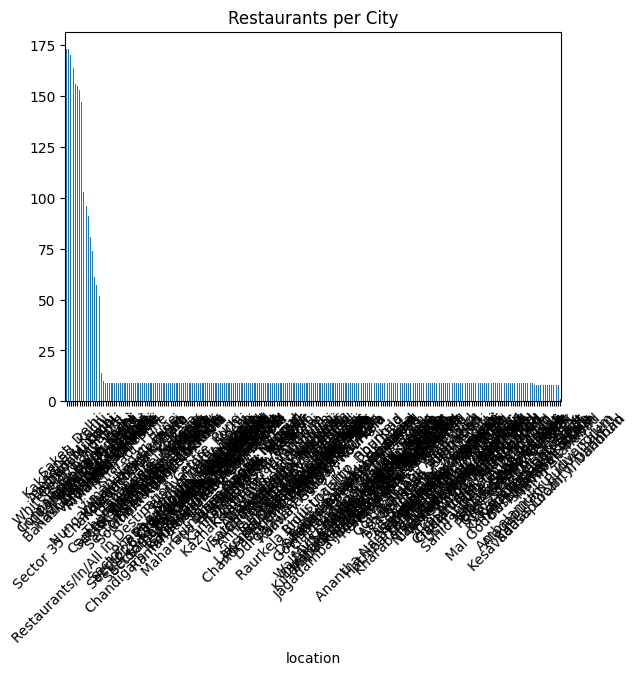

In [32]:
df['location'].value_counts().plot(kind='bar')
plt.title("Restaurants per City")
plt.xticks(rotation=45)
plt.show()

In [33]:
#bivarient  analysis

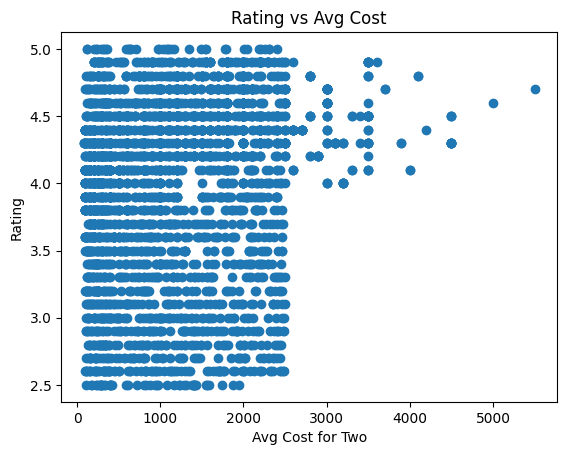

In [34]:
plt.scatter(df['avg_cost_for_two'], df['rating'])
plt.title("Rating vs Avg Cost")
plt.xlabel("Avg Cost for Two")
plt.ylabel("Rating")
plt.show()

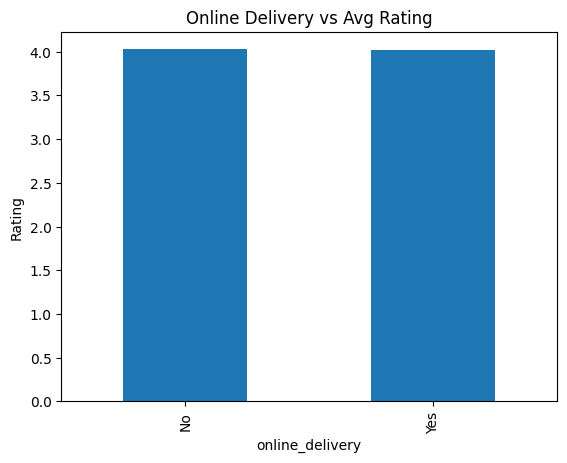

In [35]:
df.groupby('online_delivery')['rating'].mean().plot(kind='bar')
plt.title("Online Delivery vs Avg Rating")
plt.ylabel("Rating")
plt.show()

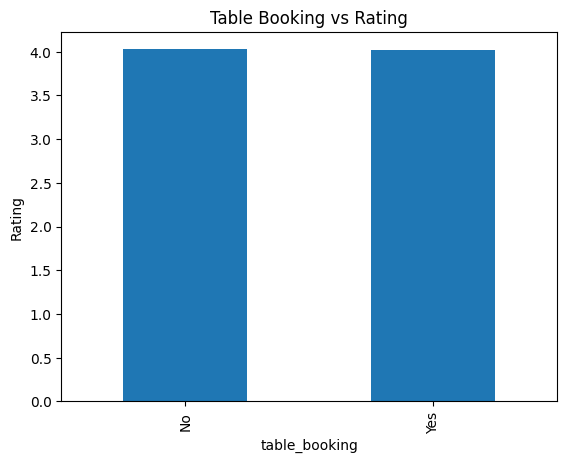

In [36]:
df.groupby('table_booking')['rating'].mean().plot(kind='bar')
plt.title("Table Booking vs Rating")
plt.ylabel("Rating")
plt.show()

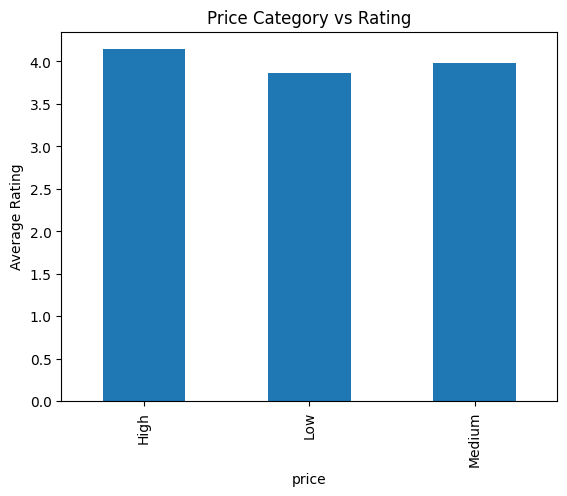

In [37]:
df.groupby('price')['rating'].mean().plot(kind='bar')
plt.title("Price Category vs Rating")
plt.ylabel("Average Rating")
plt.show()

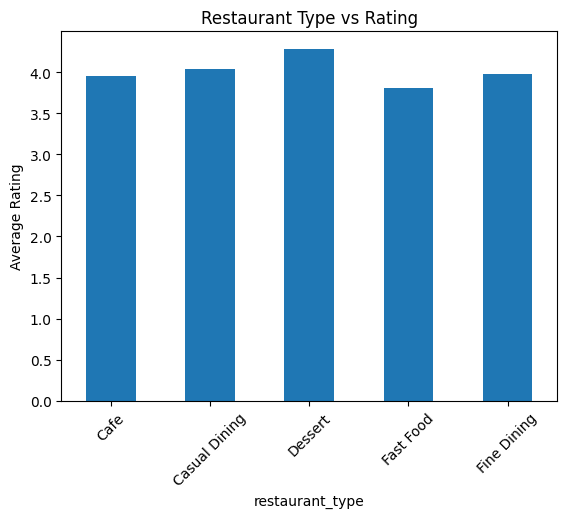

In [38]:
df.groupby('restaurant_type')['rating'].mean().plot(kind='bar')
plt.title("Restaurant Type vs Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

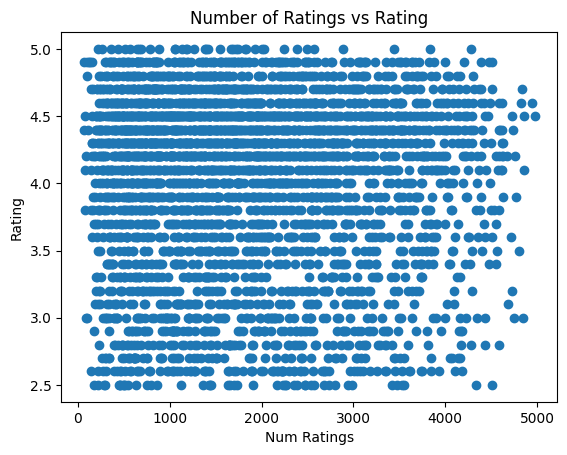

In [39]:
plt.scatter(df['num_ratings'], df['rating'])
plt.title("Number of Ratings vs Rating")
plt.xlabel("Num Ratings")
plt.ylabel("Rating")
plt.show()

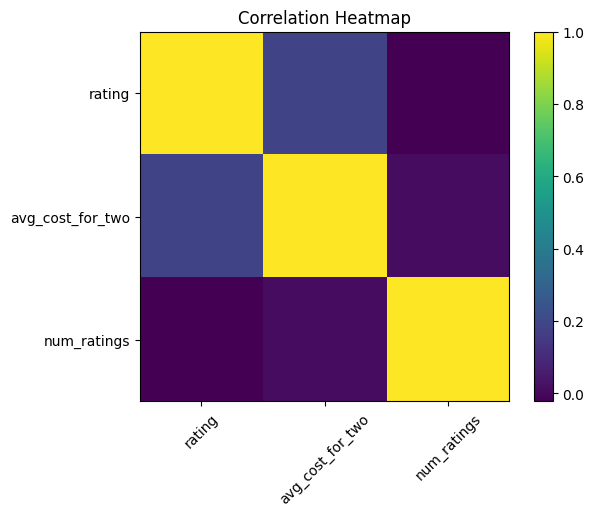

In [40]:
corr = df[['rating', 'avg_cost_for_two', 'num_ratings']].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3809 entries, 0 to 2512
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  3809 non-null   object 
 1   url                   3809 non-null   object 
 2   rating                3735 non-null   float64
 3   location              3809 non-null   object 
 4   city                  3809 non-null   object 
 5   area                  3809 non-null   object 
 6   cuisine               3399 non-null   object 
 7   price                 3808 non-null   object 
 8   reviews               3809 non-null   int64  
 9   restaurant_type       3809 non-null   object 
 10  num_ratings           3809 non-null   int64  
 11  online_delivery       3809 non-null   object 
 12  table_booking         3809 non-null   object 
 13  avg_cost_for_two      3808 non-null   float64
 14  is_delivering_now     3809 non-null   object 
 15  switch_to_order_menu  3809

In [42]:
df.describe()

,rating,reviews,num_ratings,avg_cost_for_two
count,3735.000000,3809.000000,3809.000000,3808.000000
mean,4.023400,1792.354686,1848.199002,1147.137868
std,0.635736,1346.786677,1115.603280,828.034125
min,2.500000,11.000000,65.000000,80.000000
25%,3.600000,677.000000,908.000000,400.000000
50%,4.200000,1428.000000,1667.000000,1000.000000
75%,4.500000,2709.000000,2625.000000,1763.000000
max,5.000000,5000.000000,4972.000000,5500.000000


In [46]:
#df['success'] = df['rating'].apply(lambda x: 1 if x >= 4.0 else 0)